# Customer Churn Prediction
## Project Overview

Customer churn prediction helps telecom companies identify customers who are likely to leave their services. By predicting churn early, companies can improve customer retention strategies, provide better offers, and reduce revenue loss.

In this project, machine learning models are used to analyze customer behavior and predict whether a customer is likely to churn or not.

In [100]:
## Importing Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
## Loading the Dataset
import pandas as pd
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Understanding the Dataset
Checking dataset shape, column names, missing values, and data types.

In [102]:
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [103]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [104]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


# Data Cleaning

In [105]:
df.duplicated().sum()

np.int64(0)

In [106]:
df['TotalCharges'].dtype

dtype('O')

In [107]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [108]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Missing values occured in TotalCharges

In [109]:
df.dropna(inplace=True)

In [110]:
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

In [111]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


## Encoding Categorical Features

Machine learning models cannot understand categorical values directly, so they are converted into numerical format.

In [112]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [113]:
for col in df.columns:
  print(col,df[col].unique())

gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges [  29.85 1889.5   

In [114]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [115]:
df = pd.get_dummies(df, drop_first=True)
df=df.astype(int)
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29,29,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56,1889,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53,108,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42,1840,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70,151,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


In [116]:
df.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='object')

In [117]:
df.shape

(7032, 31)

In [118]:
X = df.drop('Churn_Yes', axis=1)

y = df['Churn_Yes']

## Splitting Training and Testing Data
The dataset was divided into training and testing sets to evaluate model performance on unseen data.

In [119]:
from sklearn.model_selection import train_test_split

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [121]:
X_train.shape

X_test.shape

(1407, 30)

In [122]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Logistic Regression Classifier
Logistic Regression was used as a baseline classification model for customer churn prediction.

In [123]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced')

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced')

In [124]:
y_pred = model.predict(X_test_scaled)
y_pred

array([0, 0, 1, ..., 0, 0, 0])

In [125]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7313432835820896


In [126]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[733 300]
 [ 78 296]]


In [127]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



## Exploratory Data Analysis

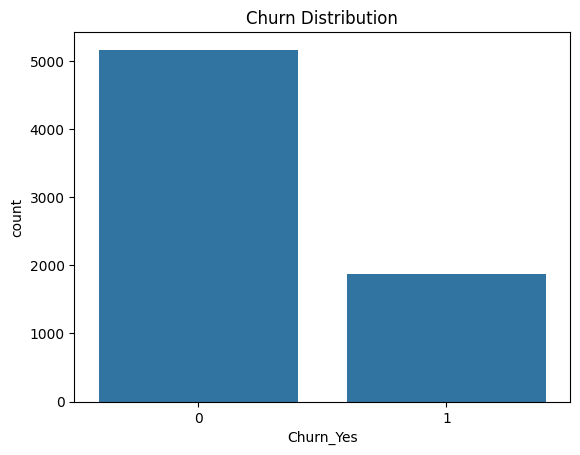

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

y = df['Churn_Yes'] # Re-defining y
sns.countplot(x=y)
plt.title("Churn Distribution")
plt.show()

Customers who stayed are more when comapred to churn. So the dataset is imbalanced

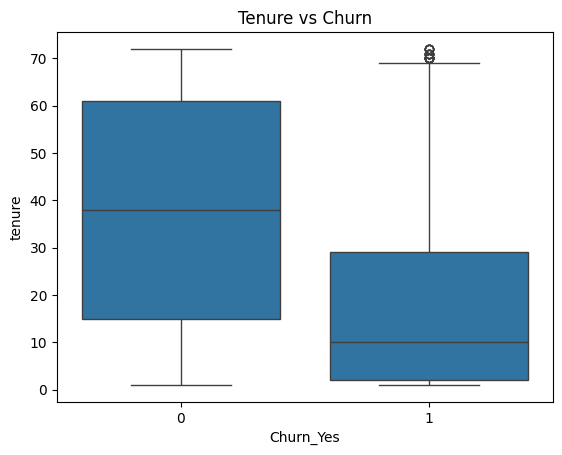

In [129]:
sns.boxplot(x=y, y=df['tenure'])
plt.title("Tenure vs Churn")
plt.show()

Customers who have low tenure are going to churn more. Means new customers are going to churn more

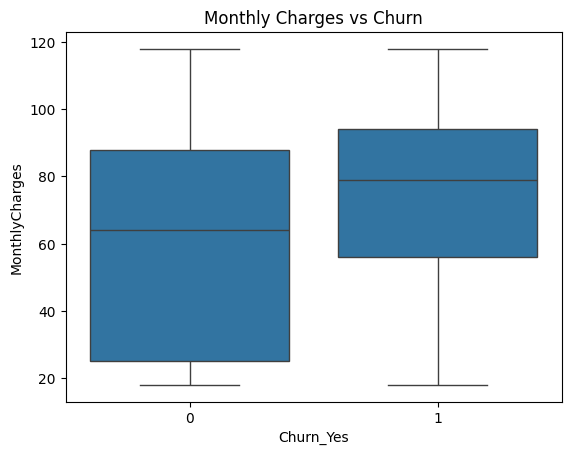

In [130]:
sns.boxplot(x=y, y=df['MonthlyCharges'])
plt.title("Monthly Charges vs Churn")
plt.show()


High monthly-charges customers are going to churn more

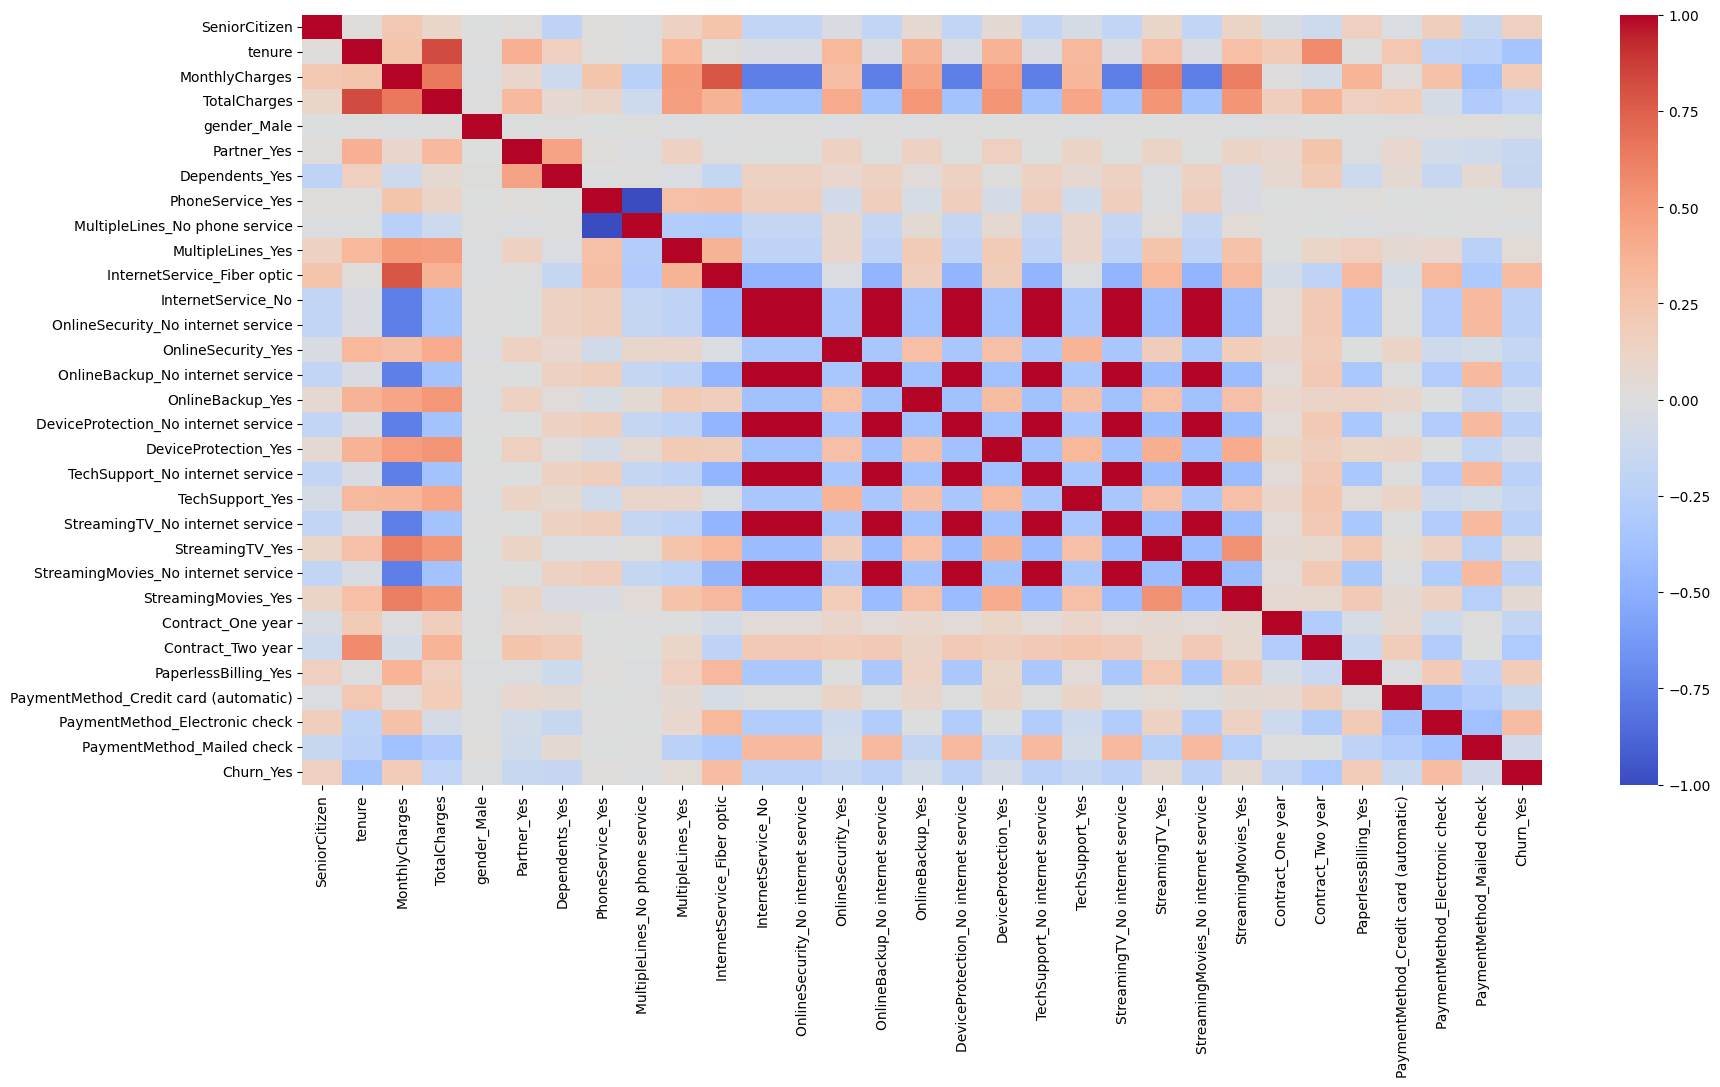

In [131]:
plt.figure(figsize=(20,10))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.show()

It shows the relationship between all the columns. +1 refers to strong positive, -1 refers to the strong negative and 0 refers to the no relation

In [132]:
corr = df.corr()['Churn_Yes'].sort_values(ascending=False)

print(corr)

Churn_Yes                                1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
MonthlyCharges                           0.192922
PaperlessBilling_Yes                     0.191454
SeniorCitizen                            0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService_Yes                         0.011691
gender_Male                             -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner_Yes                             -0.149982
Dependents_Yes                          -0.163128
TechSupport_Yes                         -0.164716
OnlineSecurity_Yes                      -0.171270


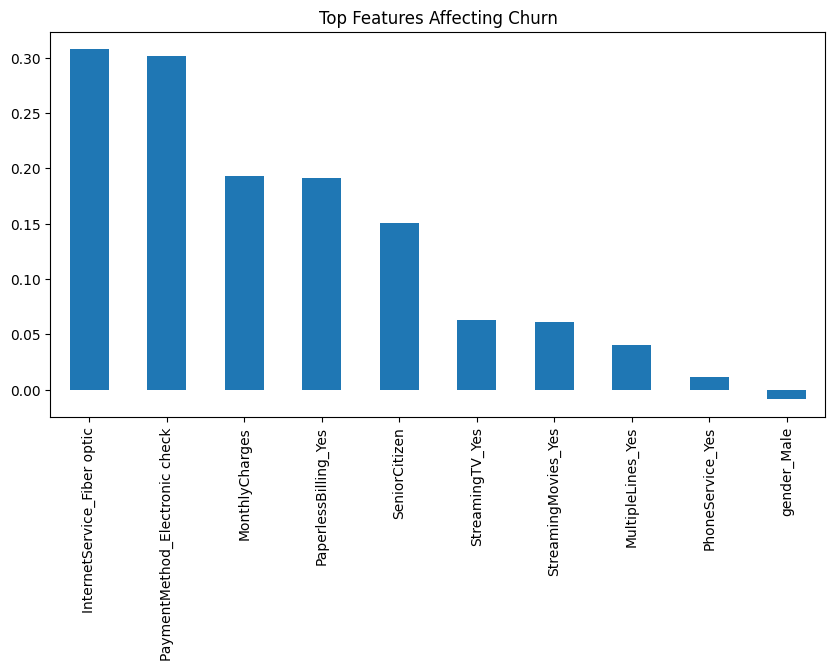

In [133]:
top_features = corr[1:11]

plt.figure(figsize=(10,5))

top_features.plot(kind='bar')

plt.title("Top Features Affecting Churn")

plt.show()

## Random Forest Classifier
Random Forest was used to improve prediction accuracy using multiple decision trees.

In [134]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test, rf_pred)
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.46      0.53       374

    accuracy                           0.78      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [135]:
importance = rf_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': X.columns,'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance',ascending=False)
print(feature_importance.head(10))

                           Feature  Importance
3                     TotalCharges    0.191443
1                           tenure    0.182800
2                   MonthlyCharges    0.135892
10     InternetService_Fiber optic    0.040596
28  PaymentMethod_Electronic check    0.038107
4                      gender_Male    0.031465
25               Contract_Two year    0.030947
13              OnlineSecurity_Yes    0.029370
26            PaperlessBilling_Yes    0.027456
5                      Partner_Yes    0.026028


## XGBoost Classifier
XGBoost was implemented as an advanced boosting algorithm for optimized churn prediction performance.

In [136]:
!pip install xgboost

In [137]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)


In [138]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, xgb_pred)
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.82      0.87      0.85      1033
           1       0.57      0.49      0.53       374

    accuracy                           0.77      1407
   macro avg       0.70      0.68      0.69      1407
weighted avg       0.76      0.77      0.76      1407



<Figure size 1000x800 with 0 Axes>

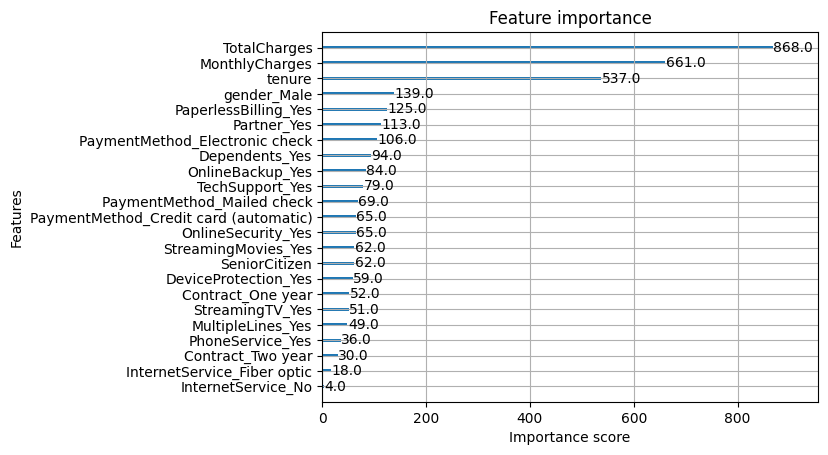

In [139]:
from xgboost import plot_importance

plt.figure(figsize=(10,8))

plot_importance(xgb_model)

plt.show()

In [140]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],

    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
     'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ]
})

comparison

,Model,Accuracy,Precision,F1 Score,Recall
0,Logistic Regression,0.731343,0.496644,0.610309,0.791444
1,Random Forest,0.784648,0.629091,0.533128,0.462567
2,XGBoost,0.766880,0.571429,0.528736,0.491979


Among Logistic Regression, Random Forest, and XGBoost, Logistic Regression achieved the best performance with higher recall and F1-score for churn prediction.

## Saving the Trained Model

The trained model is saved using joblib so it can be reused later without training again.

In [141]:
import joblib
joblib.dump(model, 'churn_model.pkl')

['churn_model.pkl']

In [142]:
loaded_model = joblib.load('churn_model.pkl')
loaded_model.predict(X_test_scaled)

array([0, 0, 1, ..., 0, 0, 0])

In [143]:
sample = X_test_scaled[0].reshape(1, -1)

prediction = model.predict(sample)

print(prediction)

[0]


In [144]:
model.predict_proba(X_test_scaled)

array([[0.98398134, 0.01601866],
       [0.71813712, 0.28186288],
       [0.15109628, 0.84890372],
       ...,
       [0.78083298, 0.21916702],
       [0.50822204, 0.49177796],
       [0.99384027, 0.00615973]])

In [145]:
churn_prob = model.predict_proba(X_test_scaled)[:,1]
print(churn_prob[:10])

[0.01601866 0.28186288 0.84890372 0.27355763 0.59636546 0.68685454
 0.30069824 0.89257362 0.43983447 0.0533003 ]


In [146]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Churn_Probability': churn_prob
})
results.head()

,Actual,Predicted,Churn_Probability
2481,0,0,0.016019
6784,0,0,0.281863
6125,1,1,0.848904
3052,0,0,0.273558
4099,0,1,0.596365


## ROC-AUC Analysis

ROC-AUC score was used to evaluate the model’s ability to distinguish between churn and non-churn customers. A higher AUC score indicates better classification performance.

In [147]:
from sklearn.metrics import roc_curve, roc_auc_score
auc = roc_auc_score(y_test, churn_prob)

print(auc)

0.8317035165733986


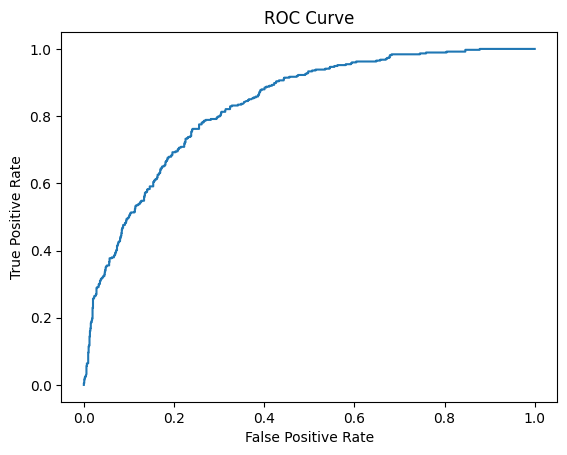

In [148]:
fpr, tpr, thresholds = roc_curve(y_test, churn_prob)
plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [149]:
results.sort_values(
    by='Churn_Probability',
    ascending=False
).head(10)

,Actual,Predicted,Churn_Probability
1976,1,1,0.939510
6368,1,1,0.936536
3159,0,1,0.935923
997,1,1,0.935110
5783,1,1,0.927677
5933,1,1,0.923947
2577,1,1,0.922655
3346,0,1,0.921972
1600,1,1,0.920928
1148,1,1,0.919228


## SHAP Explainability
SHAP values were used to interpret feature importance and understand the impact of features on churn prediction.

In [150]:
!pip install shap

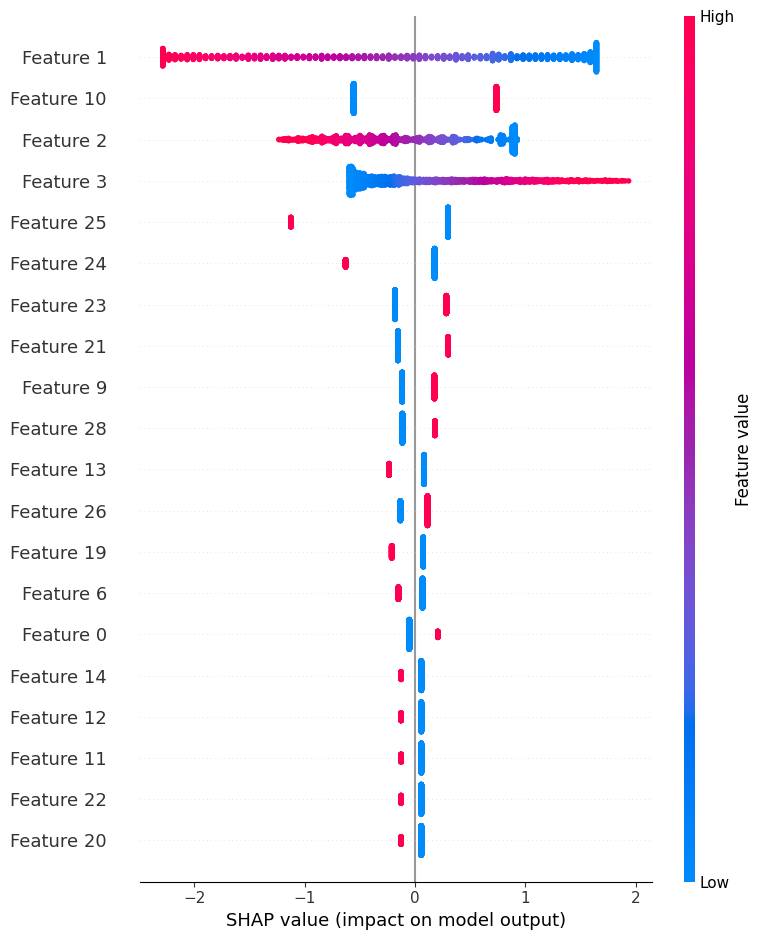

In [151]:
import shap
explainer = shap.Explainer(model, X_train_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)

## Customer Lifetime Value (LTV)
Customer Lifetime Value was estimated to identify high-value customers for retention strategies.

In [152]:
df['LTV'] = df['MonthlyCharges'] * df['tenure']
df[['MonthlyCharges', 'tenure', 'LTV']].head()
df.sort_values(by='LTV', ascending=False).head(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes,LTV
6118,0,72,118,8547,1,0,0,1,0,1,...,0,1,0,1,1,0,1,0,0,8496
4586,0,72,118,8672,0,1,1,1,0,1,...,0,1,0,1,1,0,0,0,0,8496
3205,0,72,117,8308,0,1,1,1,0,1,...,0,1,0,1,1,0,0,0,0,8424
4610,0,72,117,8684,1,1,0,1,0,1,...,0,1,1,0,1,0,0,0,1,8424
2368,0,72,117,8529,0,1,0,1,0,1,...,0,1,0,1,1,1,0,0,0,8424
4155,1,72,117,8436,0,0,0,1,0,1,...,0,1,0,1,1,1,0,0,0,8424
6768,0,72,117,8670,0,1,1,1,0,1,...,0,1,0,1,0,1,0,0,0,8424
2115,0,71,118,8477,0,0,0,1,0,1,...,0,1,0,1,1,0,1,0,0,8378
464,1,72,116,8404,1,1,0,1,0,1,...,0,1,0,1,1,0,0,0,0,8352
1746,0,72,116,8013,0,0,0,1,0,1,...,0,1,0,1,1,0,0,0,0,8352


## Streamlit Dashboard Development
A Streamlit dashboard was created to provide an interactive interface for churn prediction.

In [ ]:
!pip install streamlit

In [ ]:
%%writefile app.py

import streamlit as st

st.title("Telecom Customer Churn Prediction")

st.write("ML Project Dashboard")

In [ ]:
!pip install pyngrok

In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("3EG4m8GMjPpBYxAZ8E5362ginuJ_wotJB3DgYyzPSf6vhhMc")
!streamlit run app.py &>/dev/null&
public_url = ngrok.connect(8501)
print(public_url)

In [ ]:
X_small = df[['tenure', 'MonthlyCharges']]

y_small = df['Churn_Yes']

In [ ]:
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

small_model = LogisticRegression()

small_model.fit(X_train_s, y_train_s)

In [ ]:
import joblib

joblib.dump(small_model, "small_churn_model.pkl")

In [ ]:
%%writefile app.py

import streamlit as st
import joblib
import numpy as np

model = joblib.load("small_churn_model.pkl")

st.title("Telecom Customer Churn Prediction")

st.write("Enter Customer Details")

tenure = st.number_input("Enter Tenure")

monthly = st.number_input("Enter Monthly Charges")

if st.button("Predict"):

    data = np.array([[tenure, monthly]])

    prediction = model.predict(data)

    probability = model.predict_proba(data)[0][1]

    if prediction[0] == 1:
        st.error("Customer Likely to Churn")

    else:
        st.success("Customer Likely to Stay")

    st.write("Churn Probability:", round(probability, 2))

In [ ]:
!streamlit run app.py &>/dev/null&

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

## FastAPI Integration
FastAPI was used to build API endpoints for serving churn prediction results.

In [ ]:
!pip install fastapi uvicorn pyngrok nest-asyncio

In [ ]:
%%writefile api.py

from fastapi import FastAPI
import joblib
import numpy as np

app = FastAPI()

model = joblib.load("small_churn_model.pkl")

@app.get("/")

def home():
    return {"message": "Churn Prediction API"}

@app.get("/predict")

def predict(tenure: int, monthly: float):

    data = np.array([[tenure, monthly]])

    prediction = model.predict(data)[0]

    probability = model.predict_proba(data)[0][1]

    return {
        "prediction": int(prediction),
        "probability": float(probability)
    }

In [ ]:
import nest_asyncio
from pyngrok import ngrok
import uvicorn
from api import app
import threading
import time
nest_asyncio.apply()
def run_uvicorn():
    uvicorn.run(app, host="0.0.0.0", port=8000)
thread = threading.Thread(target=run_uvicorn)
thread.start()
time.sleep(5)
public_url = ngrok.connect(8000)
print(public_url)

## Conclusion

This project successfully implemented an end-to-end customer churn prediction system using Machine Learning techniques. Multiple classification models were evaluated, SHAP explainability was implemented, and deployment prototypes were developed using Streamlit and FastAPI.